In [55]:
import os,sys
sys.path.append('code')
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import pyBigWig as pybw
from pathlib import Path
from typing import Optional, List

from matplotlib.patches import FancyArrowPatch
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import average_precision_score, precision_score, recall_score, roc_auc_score
from scipy.interpolate import PchipInterpolator

In [30]:
def z_norm(header: dict, values: np.ndarray) -> np.ndarray:
    """
        Z-normalize signal values using summary statistics from a bigWig header.
    
        Args:
            header: dict with keys "sumData", "sumSquared", "nBasesCovered".
            values: raw signal values to normalize.
    
        Returns:
            Z-normalized values.
    """
    required_keys = {"sumData", "sumSquared", "nBasesCovered"}
    if not required_keys.issubset(header.keys()):
        raise ValueError(f"Header is missing required keys: {required_keys}")
    n = header["nBasesCovered"]
    if n == 0:
        raise ValueError("nBasesCovered is 0; cannot compute mean and standard deviation")
    mean = header["sumData"] / n
    mean_sq = header["sumSquared"] / n
    variance = max(mean_sq - mean**2, 0.0)
    std = np.sqrt(variance)
    if std == 0:
        raise ValueError("Standard deviation is 0; cannot perform Z-normalization")
    return (values - mean) / std

def Logistic_norm(x, px=[0, 2.0, 4.0, 6.0], py=[0.0, 0.5, 0.8, 1.0]):
    """
        Map raw values through a monotone PCHIP curve onto a probability-like scale.
    
        Args:
            x: raw values (e.g. RRA scores).
            px, py: control points of the monotone interpolation.
    
        Returns:
            Interpolated values (default range roughly [0, 1]).
    """
    x = np.asarray(x)
    return PchipInterpolator(px, py)(x)

def sliding_average(y, k, mode='valid'):
    """
        Smooth a 1-D signal with a sliding window average (convolution).
    
        Args:
            y: input signal.
            k: window size.
            mode: convolution mode, "valid" by default.
    
        Returns:
            Smoothed signal.
    """
    y = np.asarray(y)
    window = np.ones(k) / k
    smoothed = np.convolve(y, window, mode=mode)
    return smoothed

# Figure 3a


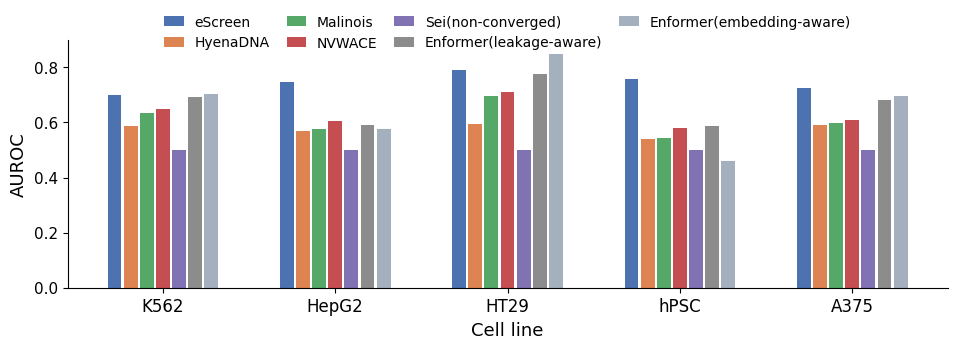

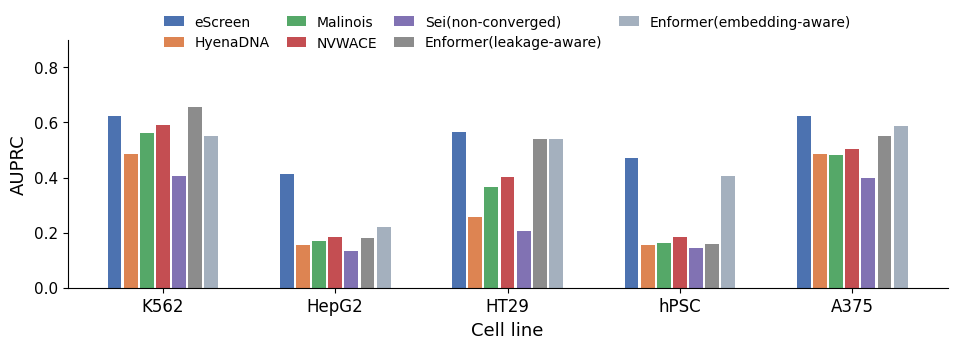

In [39]:
cell_lines = ['K562', 'HepG2', 'HT29', 'hPSC', 'A375']
n_samples = [6708, 5243, 3486, 2962, 2316]
pos_rate = [40.65, 13.41, 20.48, 14.25, 39.64]
methods_data = {
    'eScreen': {'auroc': [0.699, 0.746, 0.791, 0.758, 0.723], 'auprc': [0.623, 0.412, 0.565, 0.470, 0.623]},
    'HyenaDNA': {'auroc': [0.58815, 0.567535, 0.59372, 0.540106, 0.591062], 'auprc': [0.486199, 0.155043, 0.256709, 0.154711, 0.486164]},
    'Malinois': {'auroc': [0.635523, 0.576914, 0.693958, 0.543235, 0.598204], 'auprc': [0.563208, 0.170478, 0.365836, 0.162455, 0.482302]},
    'NVWACE': {'auroc': [0.649608, 0.604437, 0.711093, 0.580317, 0.609770], 'auprc': [0.591269, 0.183849, 0.401166, 0.182918, 0.503126]},
    'Sei(non-converged)': {'auroc': [0.500000, 0.500000, 0.500000, 0.500000, 0.500000], 'auprc': [0.4065, 0.1341, 0.2048, 0.1425, 0.3964]},
    'Enformer(leakage-aware)': {'auroc': [0.692, 0.591, 0.774, 0.586, 0.683], 'auprc': [0.656, 0.181, 0.539, 0.158, 0.549]},
    'Enformer(embedding-aware)': {'auroc': [0.7044, 0.5762, 0.8468, 0.4615, 0.6968], 'auprc': [0.5523, 0.2213, 0.5401, 0.4046, 0.5879]},
}
method_colors = {
    'eScreen': '#4C72B0', 'HyenaDNA': '#DD8452', 'Malinois': '#55A868', 'NVWACE': '#C44E52',
    'Sei(non-converged)': '#8172B3', 'Enformer(leakage-aware)': '#8C8C8C', 'Enformer(embedding-aware)': '#a4b0be',
}
fig, ax = plt.subplots(figsize=(10.0, 4))
methods = list(methods_data.keys())
x = np.arange(5) * 1.45
logical_pos = []; pos = 0.0
for method in methods:
    if method == 'Enformer-leakage-aware': pos += 1.6
    logical_pos.append(pos); pos += 1.0
logical_pos = np.array(logical_pos)
offsets = (logical_pos - logical_pos.mean()) * (0.95 / (logical_pos.max() - logical_pos.min() + 1.0))
bar_width = (0.95 / (logical_pos.max() - logical_pos.min() + 1.0)) * 0.86
for i, method in enumerate(methods):
    ax.bar(x + offsets[i], methods_data[method]['auroc'], width=bar_width, label=method, color=method_colors[method], edgecolor='none', zorder=2)
ax.set_ylabel('AUROC', fontsize=13)
ax.set_xlabel('Cell line', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(cell_lines, fontsize=12)
ax.set_ylim(0, 0.9)
ax.tick_params(axis='y', labelsize=11); ax.tick_params(axis='x', labelsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.15), handlelength=1.4, columnspacing=1.2)
plt.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
plt.savefig('figures/multi_method_AUROC_fine_tune.pdf', bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(10.0, 4))
for i, method in enumerate(methods):
    ax.bar(x + offsets[i], methods_data[method]['auprc'], width=bar_width, label=method, color=method_colors[method], edgecolor='none', zorder=2)
ax.set_ylabel('AUPRC', fontsize=13)
ax.set_xlabel('Cell line', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(cell_lines, fontsize=12)
ax.set_ylim(0, 0.9)
ax.tick_params(axis='y', labelsize=11); ax.tick_params(axis='x', labelsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.15), handlelength=1.4, columnspacing=1.2)
plt.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
plt.savefig('figures/multi_method_AUPRC_fine_tune.pdf', bbox_inches='tight')
plt.show()


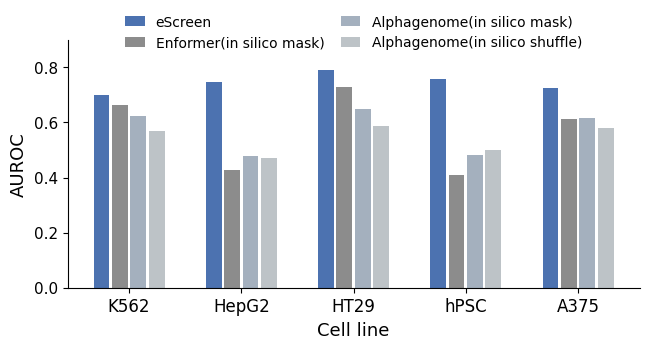

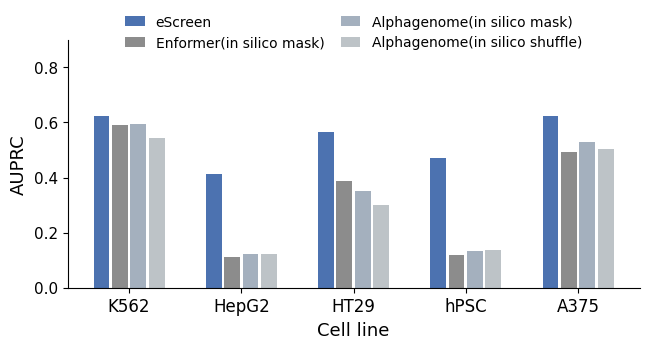

In [40]:
cell_lines = ['K562', 'HepG2', 'HT29', 'hPSC', 'A375']
methods_data = {
    'eScreen': {'auroc': [0.699, 0.746, 0.791, 0.758, 0.723], 'auprc': [0.623, 0.412, 0.565, 0.470, 0.623]},
    'Enformer(in silico mask)': {'auroc': [0.6613, 0.4286, 0.7286, 0.4099, 0.6107], 'auprc': [0.5914, 0.1125, 0.3871, 0.1189, 0.4931]},
    'Alphagenome(in silico mask)': {'auroc': [0.6218, 0.4784, 0.6474, 0.4805, 0.6142], 'auprc': [0.5930, 0.1231, 0.3501, 0.1325, 0.5291]},
    'Alphagenome(in silico shuffle)': {'auroc': [0.5677, 0.4709, 0.5865, 0.5015, 0.5780], 'auprc': [0.5443, 0.1223, 0.3018, 0.1381, 0.5035]},
}
method_colors = {
    'eScreen': '#4C72B0', 'Enformer(in silico mask)': '#8C8C8C',
    'Alphagenome(in silico mask)': '#a4b0be', 'Alphagenome(in silico shuffle)': '#bdc3c7',
}
fig, ax = plt.subplots(figsize=(6.5, 4))
methods = list(methods_data.keys())
x = np.arange(5) * 1.45
logical_pos = []; pos = 0.0
for method in methods:
    if method == 'Enformer-leakage-aware': pos += 1.6
    logical_pos.append(pos); pos += 1.0
logical_pos = np.array(logical_pos)
offsets = (logical_pos - logical_pos.mean()) * (0.95 / (logical_pos.max() - logical_pos.min() + 1.0))
bar_width = (0.95 / (logical_pos.max() - logical_pos.min() + 1.0)) * 0.86
for i, method in enumerate(methods):
    ax.bar(x + offsets[i], methods_data[method]['auroc'], width=bar_width, label=method, color=method_colors[method], edgecolor='none', zorder=2)
ax.set_ylabel('AUROC', fontsize=13)
ax.set_xlabel('Cell line', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(cell_lines, fontsize=12)
ax.set_ylim(0, 0.9)
ax.tick_params(axis='y', labelsize=11); ax.tick_params(axis='x', labelsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.15), handlelength=1.4, columnspacing=1.2)
plt.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
plt.savefig('figures/multi_method_AUROC_insilico.pdf', bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(6.5, 4))
for i, method in enumerate(methods):
    ax.bar(x + offsets[i], methods_data[method]['auprc'], width=bar_width, label=method, color=method_colors[method], edgecolor='none', zorder=2)
ax.set_ylabel('AUPRC', fontsize=13)
ax.set_xlabel('Cell line', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(cell_lines, fontsize=12)
ax.set_ylim(0, 0.9)
ax.tick_params(axis='y', labelsize=11); ax.tick_params(axis='x', labelsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.15), handlelength=1.4, columnspacing=1.2)
plt.subplots_adjust(top=0.78, bottom=0.16, left=0.10, right=0.98)
plt.savefig('figures/multi_method_AUPRC_insilico.pdf', bbox_inches='tight')
plt.show()


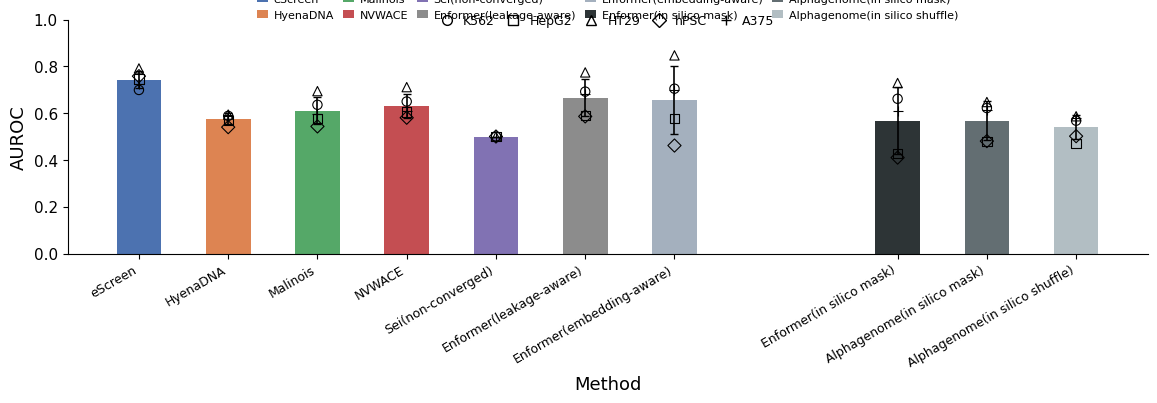

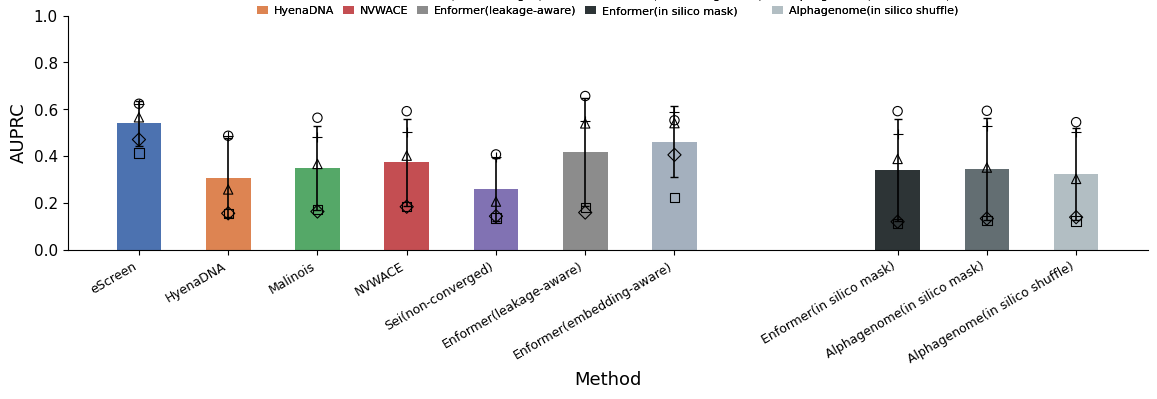

In [41]:
cell_lines = ['K562', 'HepG2', 'HT29', 'hPSC', 'A375']
methods_data = {
    'eScreen': {'auroc': [0.699, 0.746, 0.791, 0.758, 0.723], 'auprc': [0.623, 0.412, 0.565, 0.470, 0.623]},
    'HyenaDNA': {'auroc': [0.58815, 0.567535, 0.59372, 0.540106, 0.591062], 'auprc': [0.486199, 0.155043, 0.256709, 0.154711, 0.486164]},
    'Malinois': {'auroc': [0.635523, 0.576914, 0.693958, 0.543235, 0.598204], 'auprc': [0.563208, 0.170478, 0.365836, 0.162455, 0.482302]},
    'NVWACE': {'auroc': [0.649608, 0.604437, 0.711093, 0.580317, 0.609770], 'auprc': [0.591269, 0.183849, 0.401166, 0.182918, 0.503126]},
    'Sei(non-converged)': {'auroc': [0.500000, 0.500000, 0.500000, 0.500000, 0.500000], 'auprc': [0.4065, 0.1341, 0.2048, 0.1425, 0.3964]},
    'Enformer(leakage-aware)': {'auroc': [0.692, 0.591, 0.774, 0.586, 0.683], 'auprc': [0.656, 0.181, 0.539, 0.158, 0.549]},
    'Enformer(embedding-aware)': {'auroc': [0.7044, 0.5762, 0.8468, 0.4615, 0.6968], 'auprc': [0.5523, 0.2213, 0.5401, 0.4046, 0.5879]},
    'Enformer(in silico mask)': {'auroc': [0.6613, 0.4286, 0.7286, 0.4099, 0.6107], 'auprc': [0.5914, 0.1125, 0.3871, 0.1189, 0.4931]},
    'Alphagenome(in silico mask)': {'auroc': [0.6218, 0.4784, 0.6474, 0.4805, 0.6142], 'auprc': [0.5930, 0.1231, 0.3501, 0.1325, 0.5291]},
    'Alphagenome(in silico shuffle)': {'auroc': [0.5677, 0.4709, 0.5865, 0.5015, 0.5780], 'auprc': [0.5443, 0.1223, 0.3018, 0.1381, 0.5035]},
}
method_colors = {
    'eScreen': '#4C72B0', 'HyenaDNA': '#DD8452', 'Malinois': '#55A868', 'NVWACE': '#C44E52',
    'Sei(non-converged)': '#8172B3', 'Enformer(leakage-aware)': '#8C8C8C', 'Enformer(embedding-aware)': '#a4b0be',
    'Enformer(in silico mask)': '#2d3436', 'Alphagenome(in silico mask)': '#636e72', 'Alphagenome(in silico shuffle)': '#b2bec3',
}
cell_markers = {'K562': 'o', 'HepG2': 's', 'HT29': '^', 'hPSC': 'D', 'A375': '+'}
methods = list(methods_data.keys()); gap_idx = 7; group_spacing = 1.0; gap_size = 1.5
x = np.arange(len(methods), dtype=float)
for i in range(gap_idx, len(methods)): x[i] += gap_size
x *= group_spacing
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, method in enumerate(methods):
    vals = np.array(methods_data[method]['auroc']); mean_val = np.mean(vals); std_val = np.std(vals, ddof=1)
    ax.bar(x[i], mean_val, width=0.5, color=method_colors[method], edgecolor='none', zorder=2, label=method)
    ax.errorbar(x[i], mean_val, yerr=std_val, fmt='none', ecolor='black', capsize=3, capthick=1, linewidth=1.2, zorder=3)
    for j, cl in enumerate(cell_lines):
        mk = cell_markers[cl]
        if mk == '+': ax.scatter(x[i], vals[j], marker=mk, s=45, c='black', linewidths=0.8, zorder=4)
        else: ax.scatter(x[i], vals[j], marker=mk, s=45, facecolors='none', edgecolors='black', linewidths=0.8, zorder=4)
ax.set_ylabel('AUROC', fontsize=13); ax.set_xlabel('Method', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=9, rotation=30, ha='right')
ax.set_ylim(0, 1.0); ax.tick_params(axis='y', labelsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
legend1 = ax.legend(frameon=False, fontsize=8, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.15), handlelength=1.0, columnspacing=0.8, handletextpad=0.5)
legend2_handles = [plt.Line2D([0],[0], marker=cell_markers[cl], linestyle='None', color='black', markerfacecolor='none', markeredgecolor='black', markersize=7, label=cl) for cl in cell_lines]
legend2 = ax.legend(handles=legend2_handles, frameon=False, fontsize=9, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.07), handlelength=1.0, columnspacing=1.0)
ax.add_artist(legend1)
plt.subplots_adjust(top=0.80, bottom=0.28, left=0.08, right=0.98)
plt.savefig('figures/multi_method_AUROC_combined.pdf', bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, method in enumerate(methods):
    vals = np.array(methods_data[method]['auprc']); mean_val = np.mean(vals); std_val = np.std(vals, ddof=1)
    ax.bar(x[i], mean_val, width=0.5, color=method_colors[method], edgecolor='none', zorder=2, label=method)
    ax.errorbar(x[i], mean_val, yerr=std_val, fmt='none', ecolor='black', capsize=3, capthick=1, linewidth=1.2, zorder=3)
    for j, cl in enumerate(cell_lines):
        mk = cell_markers[cl]
        if mk == '+': ax.scatter(x[i], vals[j], marker=mk, s=45, c='black', linewidths=0.8, zorder=4)
        else: ax.scatter(x[i], vals[j], marker=mk, s=45, facecolors='none', edgecolors='black', linewidths=0.8, zorder=4)
ax.set_ylabel('AUPRC', fontsize=13); ax.set_xlabel('Method', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=9, rotation=30, ha='right')
ax.set_ylim(0, 1.0); ax.tick_params(axis='y', labelsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
legend1 = ax.legend(frameon=False, fontsize=8, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.15), handlelength=1.0, columnspacing=0.8, handletextpad=0.5)
ax.add_artist(legend1)
plt.subplots_adjust(top=0.80, bottom=0.28, left=0.08, right=0.98)
plt.savefig('figures/multi_method_AUPRC_combined.pdf', bbox_inches='tight')
plt.show()


# Figure 3b

NRF1 chr17:1595744-1695744 (SCARF1)
saved figures/NRF1_chr17_1595744_1695744.pdf


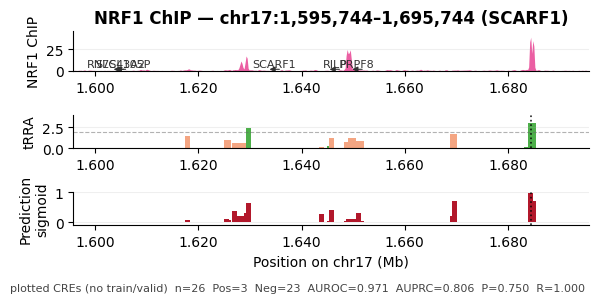

MXI1 chr2:197400613-197600613 (HSPD1)
saved figures/MXI1_chr2_197400613_197600613.pdf


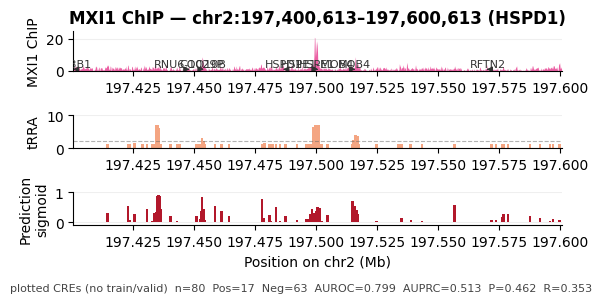

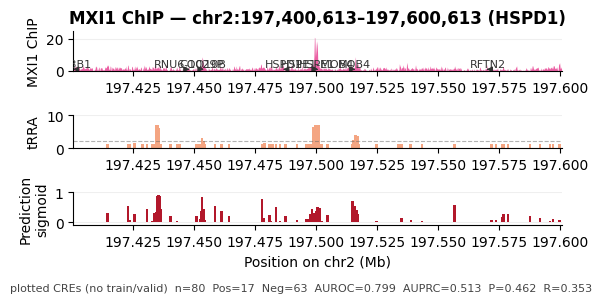

In [48]:
RRA_CAP_VALUE = 3.0
RRA_YLIM = 4.0
CRE_BAR_WIDTH_FRAC = 2.0
PRED_YLIM = (-0.1, 1.0)
HIDE_LEAKED = True
SPLIT_COLORS = {
    "test": "#4DAF4A",
    "neither": "#F4A582",
    "not_in_721": "#BDBDBD",
    "locus_holdout": "#FF7F00",
    "showcase": "#F4A582",
}
def locus_prefix(tf, chrom, start, end):
    """
        Build the data-file prefix for a locus, e.g. f"{tf}_{chrom}_{start}_{end}".
    """
    return f"{tf}_{chrom}_{start}_{end}"
def normalize_score(x):
    """
        Sigmoid mapping of raw scores to (0, 1): 1 / (1 + exp(-2 * (x - 2))).
    """
    x = np.asarray(x, dtype=float)
    return 1 / (1 + np.exp(-2 * (x - 2.0)))
def cre_bar_width(df, fill=CRE_BAR_WIDTH_FRAC):
    """
        Bar width proportional to CRE span (span * fill), with a minimum of 1.
    """
    span = (df["end"].astype(float) - df["start"].astype(float)).to_numpy()
    return np.maximum(span * fill, 1.0)
def load_cre_table(prefix: str, data_dir: Path) -> pd.DataFrame:
    """
        Load a CRE score table for a locus; optionally drop train/valid CREs (leakage).
    
        Args:
            prefix: locus file prefix.
            data_dir: directory containing the "<prefix>_cre_scores.tsv" files.
    
        Returns:
            DataFrame of CRE scores (filtered when HIDE_LEAKED is True).
    """
    cre = pd.read_csv(f"{data_dir}/{prefix}_cre_scores.tsv", sep="\t")
    raw_path = f"{data_dir}/raw/{prefix}_cre_scores_raw.tsv"
    if HIDE_LEAKED and os.path.exists(raw_path):
        raw = pd.read_csv(raw_path, sep="\t")[["id", "split_721"]]
        cre = cre.merge(raw, on="id", how="left")
        cre = cre.loc[~cre["split_721"].isin(["train", "valid"])].copy()
    elif raw_path.is_file():
        raw = pd.read_csv(raw_path, sep="\t")[["id", "split_721"]]
        cre = cre.merge(raw, on="id", how="left")
    return cre
def bar_colors(splits: pd.Series) -> List[str]:
    """
        Map split labels (test/train/valid/...) to plot colors.
    """
    return [SPLIT_COLORS.get(str(sp), "#F4A582") for sp in splits.astype(str)]
def compute_metrics_from_cre(
    cre,
    rra_col="RRA",
    score_col="score",
    rra_threshold=2.0,
    pred_threshold=0.5,
):
    """
        Compute AUROC, AUPRC, precision and recall from a CRE table.
    
        Args:
            cre: CRE DataFrame with RRA and score columns.
            rra_threshold: functional threshold on RRA (default 2.0).
            pred_threshold: decision threshold on the normalized score (default 0.5).
    
        Returns:
            dict with n, n_pos, n_neg, positive_rate, auroc, auprc, precision, recall.
    """
    df = cre.copy()
    y_true = (df[rra_col].astype(float) > rra_threshold).astype(int)
    y_score = normalize_score(df[score_col].astype(float))
    y_pred = (y_score >= pred_threshold).astype(int)
    if len(np.unique(y_true)) < 2:
        auroc = np.nan
        auprc = np.nan
    else:
        auroc = roc_auc_score(y_true, y_score)
        auprc = average_precision_score(y_true, y_score)
    return {
        "n": len(df),
        "n_pos": int(y_true.sum()),
        "n_neg": int((1 - y_true).sum()),
        "positive_rate": float(y_true.mean()) if len(df) else np.nan,
        "auroc": auroc,
        "auprc": auprc,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }
def metrics_footer_from_cre(cre: pd.DataFrame) -> str:
    """
        Build the metrics footer text shown under a locus plot.
    """
    m = compute_metrics_from_cre(cre)
    leak_note = "plotted CREs (no train/valid)" if HIDE_LEAKED else "all window CREs"
    return (
        f"{leak_note}  n={m['n']}  Pos={m['n_pos']}  Neg={m['n_neg']}  "
        f"AUROC={m['auroc']:.3f}  AUPRC={m['auprc']:.3f}  "
        f"P={m['precision']:.3f}  R={m['recall']:.3f}"
    )
def plot_gene_track_inside_chip(ax, genes, y_frac=0.08):
    """
        Draw gene names and strand arrows inside the ChIP track.
    
        Args:
            ax: matplotlib axis.
            genes: DataFrame with gene_name, gstart, gend, strand.
            y_frac: vertical position of the track as a fraction of the y-range.
    """
    if genes.empty:
        return
    ymin, ymax = ax.get_ylim()
    y = ymin + (ymax - ymin) * y_frac
    seen = set()
    for _, row in genes.iterrows():
        name = str(row["gene_name"])
        if name in seen:
            continue
        seen.add(name)
        gstart, gend = int(row["gstart"]), int(row["gend"])
        strand = str(row["strand"])
        mid = (gstart + gend) / 2.0
        ax.text(mid, y, name, ha="center", va="bottom", fontsize=8,
                color="#333333", clip_on=True)
        dx = 3000 if strand == "+" else -3000
        ax.add_patch(
            FancyArrowPatch(
                (mid - dx / 2, y),
                (mid + dx / 2, y),
                arrowstyle="-|>",
                mutation_scale=8,
                color="#333333",
                lw=0.8,
                clip_on=True,
            )
        )
def plot_locus(
    tf,
    gene,
    chrom,
    start,
    end,
    data_dir,
    *,
    peak_cre_id: Optional[str] = None,
    rra_cap_value=RRA_CAP_VALUE,
    rra_ylim=RRA_YLIM,
    save_path=None,
):
    """
        Plot ChIP, tRRA and prediction tracks for one locus.
    
        Args:
            tf: transcription factor name.
            gene: gene label for the title.
            chrom, start, end: genomic window.
            data_dir: directory with locus data files.
            peak_cre_id: optional CRE id to highlight with a vertical line.
            rra_cap_value: cap for RRA bar heights.
            rra_ylim: y-axis limit of the tRRA track.
            save_path: optional PDF output path.
    
        Returns:
            The matplotlib figure.
    """
    prefix = locus_prefix(tf, chrom, start, end)
    cre = load_cre_table(prefix, data_dir)
    chip = pd.read_csv( f"{data_dir}/{prefix}_chip_profile.tsv", sep="\t")
    genes = pd.read_csv(f"{data_dir}/{prefix}_genes.tsv", sep="\t")
    if not cre.empty:
        cre = cre.copy()
        cre["RRA_plot"] = np.minimum(cre["RRA"].astype(float), rra_cap_value)
        cre["score_sigmoid"] = normalize_score(cre["score"])
        cre["mid"] = (cre["start"].astype(float) + cre["end"].astype(float)) / 2.0
        cre["bar_width"] = cre_bar_width(cre)
        rra_colors = bar_colors(cre["split_721"]) if "split_721" in cre.columns else ["#F4A582"] * len(cre)
    else:
        rra_colors = []
    fig = plt.figure(figsize=(6, 3))
    gs = GridSpec(3, 1, height_ratios=[1.2, 1.0, 1.0])
    ax_chip = fig.add_subplot(gs[0])
    ax_rra = fig.add_subplot(gs[1], sharex=ax_chip)
    ax_pred = fig.add_subplot(gs[2], sharex=ax_chip)
    if not chip.empty:
        ax_chip.fill_between(
            chip["center"].astype(float),
            chip["signal"].astype(float),
            color="#e84393",
            alpha=0.85,
            linewidth=0,
        )
    ax_chip.set_ylabel(f"{tf} ChIP")
    ax_chip.grid(axis="y", alpha=0.2)
    chip_ymax = ax_chip.get_ylim()[1]
    ax_chip.set_ylim(0, chip_ymax * 1.12)
    plot_gene_track_inside_chip(ax_chip, genes, y_frac=0.04)
    if not cre.empty:
        ax_rra.bar(
            cre["mid"],
            cre["RRA_plot"],
            width=cre["bar_width"],
            color=rra_colors,
            edgecolor="none",
            align="center",
            rasterized=True,
        )
        if peak_cre_id:
            peak = cre.loc[cre["id"] == peak_cre_id]
            if not peak.empty:
                pc = float(peak["mid"].iloc[0])
                for ax in (ax_rra, ax_pred):
                    ax.axvline(pc, color="#000000", ls=":", lw=1.2, alpha=0.85, zorder=5)
    ax_rra.set_ylim(0, rra_ylim)
    ax_rra.set_ylabel("tRRA")
    ax_rra.grid(axis="y", alpha=0.2)
    ax_rra.axhline(2, color="#666666", lw=0.8, ls="--", alpha=0.5)
    if not cre.empty:
        ax_pred.bar(
            cre["mid"],
            cre["score_sigmoid"],
            width=cre["bar_width"],
            color="#B2182B",
            edgecolor="none",
            align="center",
            rasterized=True,
        )
    ax_pred.set_ylim(*PRED_YLIM)
    ax_pred.set_ylabel("Prediction\nsigmoid")
    ax_pred.set_xlabel(f"Position on {chrom} (Mb)")
    ax_pred.grid(axis="y", alpha=0.2)
    mb_fmt = FuncFormatter(lambda x, _pos: f"{x / 1e6:.3f}")
    for ax in [ax_chip, ax_rra, ax_pred]:
        ax.set_xlim(float(start), float(end))
        ax.xaxis.set_major_formatter(mb_fmt)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    ax_chip.set_title(
        f"{tf} ChIP \u2014 {chrom}:{int(start):,}\u2013{int(end):,} ({gene})",
        fontsize=12,
        fontweight="bold",
    )
    if not cre.empty:
        fig.text(0.01, 0.01, metrics_footer_from_cre(cre), fontsize=8, color="#444444")
    fig.tight_layout(rect=[0, 0.035, 1, 1])
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
        print(f"saved {save_path}")
    plt.show()
    return fig

print("NRF1 chr17:1595744-1695744 (SCARF1)")
plot_locus(
    tf="NRF1",
    gene="SCARF1",
    chrom="chr17",
    start=1595744,
    end=1695744,
    data_dir="data/fig3/locus",
    peak_cre_id="EH38E3203008",
    save_path="figures/NRF1_chr17_1595744_1695744.pdf",
)
print("MXI1 chr2:197400613-197600613 (HSPD1)")
plot_locus(
    tf="MXI1",
    gene="HSPD1",
    chrom="chr2",
    start=197400613,
    end=197600613,
    data_dir="data/fig3/locus",
    peak_cre_id=None,
    rra_cap_value=7,
    rra_ylim=10,
    save_path="figures/MXI1_chr2_197400613_197600613.pdf",
)


# Figure 3c

## functional-defined peak plot

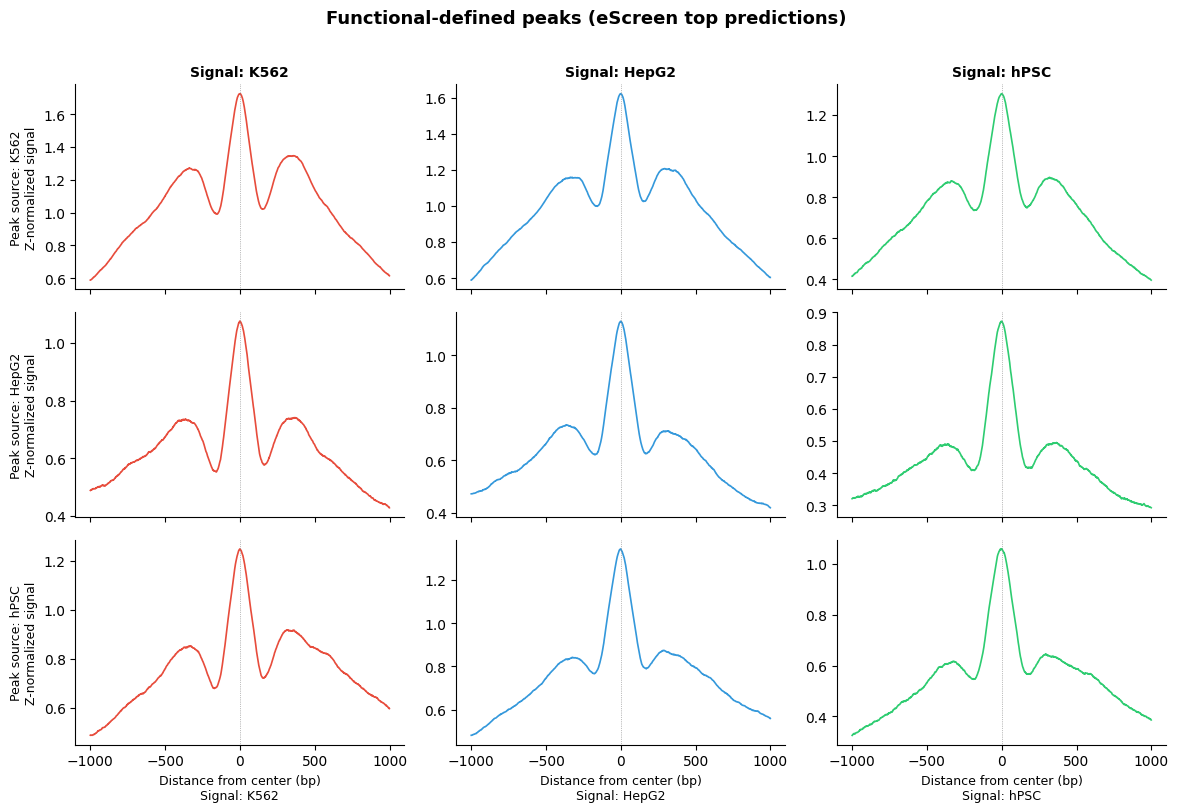

In [49]:
import numpy as np
import matplotlib.pyplot as plt
W = 2000
CELL_LINES = ['K562', 'HepG2', 'hPSC']
cmap_lines = ['#e74c3c', '#3498db', '#2ecc71']
data = np.load('data/fig3/func_peak_signals.npz')
fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=False)
for row, src_cl in enumerate(CELL_LINES):
    for col, sig_cl in enumerate(CELL_LINES):
        ax = axes[row, col]
        y = data[f'{src_cl}_{sig_cl}']
        x = np.arange(-W//2, W//2)
        ax.plot(x, y, color=cmap_lines[col], linewidth=1.2)
        ax.axvline(0, color='gray', linestyle=':', linewidth=0.5)
        if col == 0:
            ax.set_ylabel(f'Peak source: {src_cl}\nZ-normalized signal', fontsize=9)
        if row == 2:
            ax.set_xlabel(f'Distance from center (bp)\nSignal: {sig_cl}', fontsize=9)
        if row == 0:
            ax.set_title(f'Signal: {sig_cl}', fontsize=10, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
fig.suptitle('Functional-defined peaks (eScreen top predictions)', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('figures/Fig3c_func_peaks.pdf', bbox_inches='tight', dpi=300)
plt.show()

## accessibility-defined peak plot

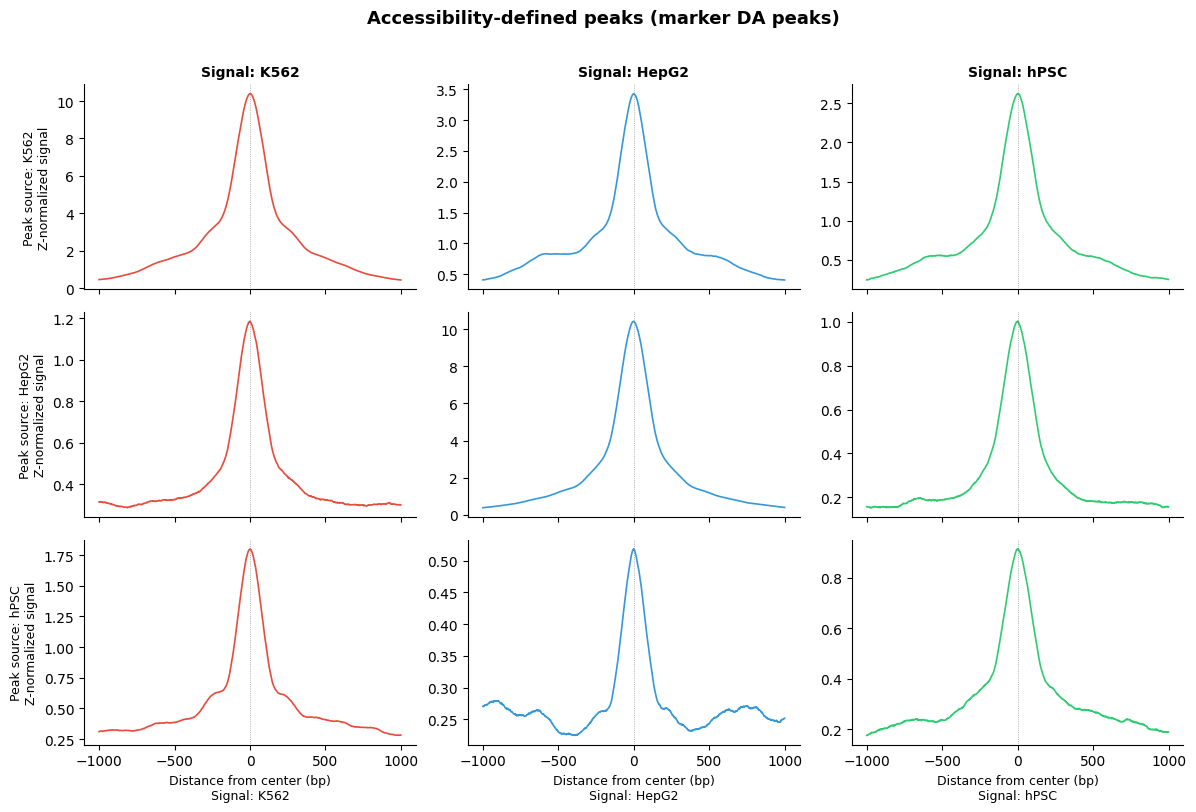

In [50]:
import numpy as np
import matplotlib.pyplot as plt
W = 2000
CELL_LINES = ['K562', 'HepG2', 'hPSC']
cmap_lines = ['#e74c3c', '#3498db', '#2ecc71']
data = np.load('data/fig3/access_peak_signals.npz')
fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=False)
for row, src_cl in enumerate(CELL_LINES):
    for col, sig_cl in enumerate(CELL_LINES):
        ax = axes[row, col]
        y = data[f'{src_cl}_{sig_cl}']
        x = np.arange(-W//2, W//2)
        ax.plot(x, y, color=cmap_lines[col], linewidth=1.2)
        ax.axvline(0, color='gray', linestyle=':', linewidth=0.5)
        if col == 0:
            ax.set_ylabel(f'Peak source: {src_cl}\nZ-normalized signal', fontsize=9)
        if row == 2:
            ax.set_xlabel(f'Distance from center (bp)\nSignal: {sig_cl}', fontsize=9)
        if row == 0:
            ax.set_title(f'Signal: {sig_cl}', fontsize=10, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
fig.suptitle('Accessibility-defined peaks (marker DA peaks)', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('figures/Fig3c_access_peaks.pdf', bbox_inches='tight', dpi=300)
plt.show()

## eQTL enrichment bar plot

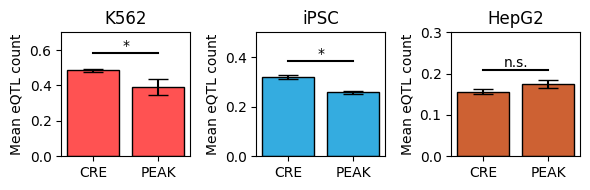

In [51]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
with open('data/fig3/eqtl_enrichment_results.pkl', 'rb') as f:
    res = pickle.load(f)
fig, axes = plt.subplots(1, 3, figsize=(6, 2))
colors = [['#ff5252','#ff5252'],['#34ace0','#34ace0'],['#cd6133','#cd6133']]
ylims = [[0.0,0.7],[0.0,0.5],[0.0,0.3]]
labels = ['CRE', 'PEAK']
tissue_keys = ['Blood', 'iPSC', 'Liver']
titles = ['K562', 'iPSC', 'HepG2']
for ax, tk, title, color, ylim in zip(axes, tissue_keys, titles, colors, ylims):
    r = res[tk]
    scale = 20 if tk == 'iPSC' else 1
    data = [r['cre_mean']/scale, r['peak_mean']/scale]
    yerr = [r['cre_sem']/scale, r['peak_sem']/scale]
    ax.bar([0, 1], data, color=color, edgecolor='black', yerr=yerr, capsize=7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel('Mean eQTL count')
    ax.set_ylim(ylim)
    pv = r['mw_pval']
    if pv < 0.001:
        star = '***'
    elif pv < 0.01:
        star = '**'
    elif pv < 0.05:
        star = '*'
    else:
        star = 'n.s.'
    max_bar = max(data)
    y_top = max_bar + max_bar * 0.2
    ax.plot([0.0, 1.0], [y_top, y_top], color='k')
    ax.text(0.5, y_top, star, va='bottom', ha='center')
plt.tight_layout()
plt.savefig('figures/Fig3c_eqtl_enrichment.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Figure 3d

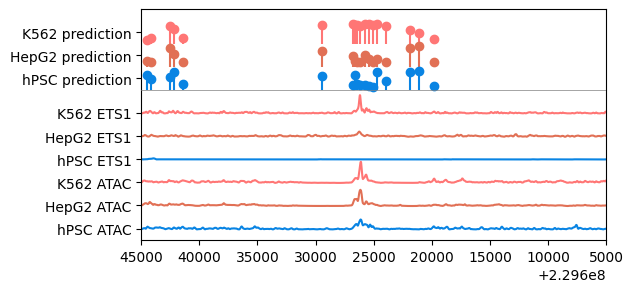

In [56]:
with open('data/fig3/track_data.pkl', 'rb') as f:
    td = pickle.load(f)
X = td['X']
signals = td['signals']
MOTIF = td['MOTIF']
START, WINDOW, CHROMO = td['START'], td['WINDOW'], td['CHROMO']
preds = pd.read_csv('data/fig3/Predictions_3cellline.txt', sep='\t')
preds = preds[~preds['chr'].isin(['chrY'])]
locus = preds[(preds['chr'] == CHROMO) & (preds['start'] >= START - WINDOW) & (preds['end'] <= START + WINDOW)]
cre_starts = ((locus['start'].values + locus['end'].values) / 2).astype(int)
cpx1 = [-7.5909, 0.4162, 1.0285, 1.6557, 9.6769]; cpy1 = [0.0, 0.25, 0.5, 0.75, 1.0]
cpx2 = [-4.7905, 0.0699, 0.4571, 0.8579, 4.3877]; cpy2 = [0.0, 0.25, 0.5, 0.75, 1.0]
cpx3 = [-3.5397, 0.1006, 0.4455, 0.7964, 3.7675]; cpy3 = [0.0, 0.25, 0.5, 0.75, 1.0]
pred_K562 = Logistic_norm(locus['pK562'].values, cpx1, cpy1)
pred_HepG2 = Logistic_norm(locus['pHepG2'].values, cpx2, cpy2)
pred_hPSC = Logistic_norm(locus['phPSC'].values, cpx3, cpy3)
plt.figure(figsize=(6, 3))
plt.stem(cre_starts, pred_K562 + 5, linefmt='#ff7675', markerfmt='#ff7675', basefmt='none', bottom=5.0)
plt.stem(cre_starts, pred_HepG2 + 4, linefmt='#e17055', markerfmt='#e17055', basefmt='none', bottom=4.0)
plt.stem(cre_starts, pred_hPSC + 3, linefmt='#0984e3', markerfmt='#0984e3', basefmt='none', bottom=3.0)
plt.plot([START - WINDOW, START + WINDOW], [3.0, 3.0], color='grey', ls='-', lw=0.5, zorder=3)
for i, cl in enumerate(['K562', 'HepG2', 'hPSC']):
    plt.plot(X, signals[f'{cl}_{MOTIF}_smooth'], color=['#ff7675', '#e17055', '#0984e3'][i])
    plt.plot(X, signals[f'{cl}_ATAC_smooth'], color=['#ff7675', '#e17055', '#0984e3'][i])
plt.yticks([-3, -2, -1, 0, 1, 2, 3.5, 4.5, 5.5],
           ['hPSC ATAC', 'HepG2 ATAC', 'K562 ATAC',
            f'hPSC {MOTIF}', f'HepG2 {MOTIF}', f'K562 {MOTIF}',
            'hPSC prediction', 'HepG2 prediction', 'K562 prediction'])
plt.ylim([-3.5, 6.5])
plt.xlim([START + WINDOW, START - WINDOW])
plt.savefig('figures/Fig3d_track.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3g

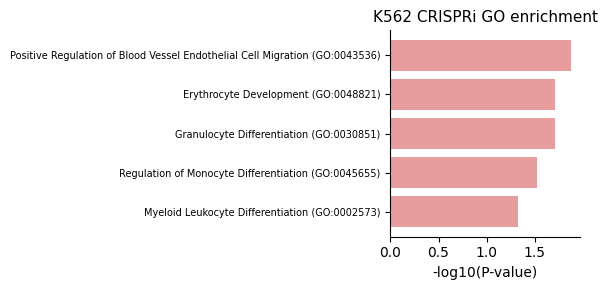

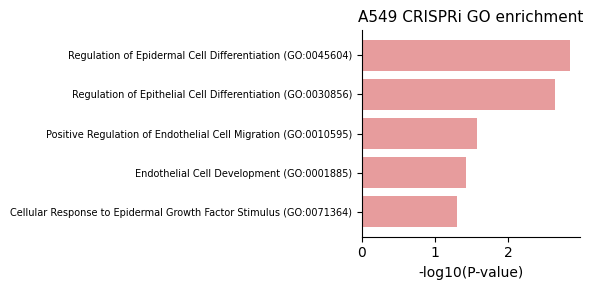

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
BASE = 'data/fig3'
K562Ki = pd.read_csv(f'{BASE}/K562Ki.txt', sep='\t')
A549Ki = pd.read_csv(f'{BASE}/A549Ki.txt', sep='\t')
fig, ax = plt.subplots(figsize=(6, 3))
K562Ki_sorted = K562Ki.head(10)
y = -np.log10(K562Ki_sorted['P-value'].values)
colors = ['#e79c9d' if i < 5 else '#95afc0' for i in range(len(K562Ki_sorted))]
ax.barh(range(len(K562Ki_sorted)), y, color=colors)
ax.set_yticks(range(len(K562Ki_sorted)))
ax.set_yticklabels(K562Ki_sorted['Term'].values, fontsize=7)
ax.set_xlabel('-log10(P-value)', fontsize=10)
ax.set_title('K562 CRISPRi GO enrichment', fontsize=11)
ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/Fig3g_K562_GO.png', dpi=300, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(6, 3))
A549Ki_sorted = A549Ki.head(10)
y = -np.log10(A549Ki_sorted['P-value'].values)
colors = ['#e79c9d' if i < 5 else '#95afc0' for i in range(len(A549Ki_sorted))]
ax.barh(range(len(A549Ki_sorted)), y, color=colors)
ax.set_yticks(range(len(A549Ki_sorted)))
ax.set_yticklabels(A549Ki_sorted['Term'].values, fontsize=7)
ax.set_xlabel('-log10(P-value)', fontsize=10)
ax.set_title('A549 CRISPRi GO enrichment', fontsize=11)
ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/Fig3g_A549_GO.png', dpi=300, bbox_inches='tight')
plt.show()


# Figure 3h

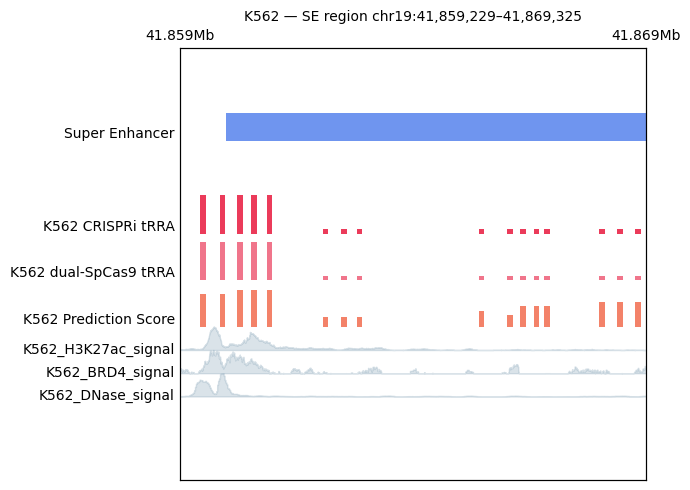

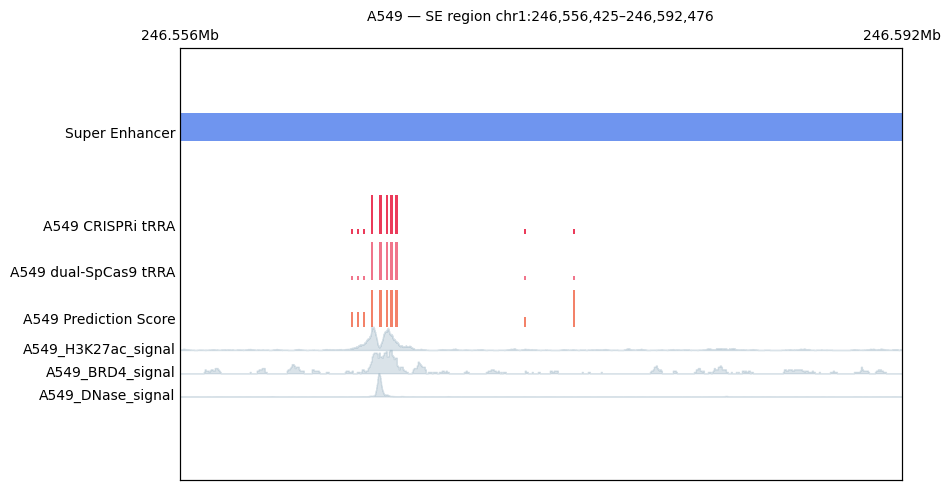

In [58]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
MIN_H = 0.1
with open('data/fig3/locus_data.pkl', 'rb') as f:
    loci = pickle.load(f)
for locus_name in loci:
    d = loci[locus_name]
    st, en = d['start'], d['end']
    se_st = max(d['se_start'], st)
    se_en = min(d['se_end'], en)
    cell_label = 'K562' if 'K562' in locus_name else 'A549'
    fig, ax = plt.subplots(figsize=((en - st) / 10000 + 6, 5))
    rect = patches.Rectangle(
        (se_st, 3.5), se_en - se_st, 0.6,
        edgecolor=None, facecolor='#4b7bec', alpha=0.8, linewidth=1.5
    )
    ax.add_patch(rect)
    x = np.arange(st, en)
    for ti, (tname, sig) in enumerate(d['tracks'].items()):
        y_base = -1.0 - 0.5 * ti
        valid_len = min(len(x), len(sig))
        ax.fill_between(
            x[:valid_len], y_base,
            sig[:valid_len] / 2 + y_base,
            color='#95afc0', alpha=0.35, rasterized=True
        )
    for df, y0, color, alpha in [
        (d['crispri_df'], -0.5, '#eb2f06', 0.6),
        (d['crispri_df'], 1.5, '#eb3b5a', 1.0),
        (d['dualko_df'],  0.5, '#eb3b5a', 0.7),
    ]:
        if df.empty:
            continue
        for _, cre in df.iterrows():
            h = max(np.clip(cre['RRA'] if y0 != -0.5 else cre['prediction'], 0, 0.8 if y0 == -0.5 else 2.5) / (1 if y0 == -0.5 else 3.0), MIN_H)
            rect = patches.Rectangle(
                (cre['mid'] - 60, y0), 120, h,
                edgecolor=None, facecolor=color, alpha=alpha, linewidth=1.5
            )
            ax.add_patch(rect)
    ax.set_xlim(st, en)
    ax.set_ylim(-3.8, 5.5)
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_title(d['label'], fontsize=10)
    ax.set_xlabel('')
    ax.set_xticks([])
    track_names = list(d['tracks'].keys())
    ytick_pos = [3.5, 1.5, 0.5, -0.5] + [-1.15 - 0.5 * i for i in range(len(track_names))]
    ytick_lbl = ['Super Enhancer', f'{cell_label} CRISPRi tRRA',
                 f'{cell_label} dual-SpCas9 tRRA', f'{cell_label} Prediction Score']
    ytick_lbl += [f'{cell_label}_{n}_signal' for n in track_names]
    ax.set_yticks(ytick_pos, ytick_lbl, va='bottom')
    ax2 = ax.twiny()
    ax2.set_xlim(st, en)
    ax2.set_xticks([st, en])
    ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.3f}Mb'))
    ax2.tick_params(axis='x', length=0)
    fig.tight_layout()
plt.savefig('figures/Fig3h_locus.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Figure 3i

/cluster2/huanglab/liquan/temp/Rtemp/ipykernel_119475/739886466.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  parts = sns.violinplot(
/cluster2/huanglab/liquan/temp/Rtemp/ipykernel_119475/739886466.py:27: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  parts = sns.violinplot(


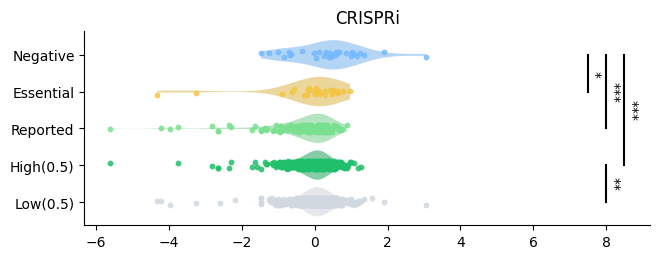

In [62]:
CRISPRi_data = pd.read_csv('data/fig3/CRISPRi_K562.annotated.txt',sep='\t')
ess_lfc  = CRISPRi_data.loc[CRISPRi_data['id'].str.contains('\*'), 'neg|lfc'].dropna()
nf_lfc   = CRISPRi_data.loc[CRISPRi_data['id'].str.contains('#'), 'neg|lfc'].dropna()
rep_lfc  = CRISPRi_data.loc[CRISPRi_data['RRA'] > 0, 'neg|lfc'].dropna()
high_lfc = CRISPRi_data.loc[CRISPRi_data['Base_K562_pred'] > 0.5, 'neg|lfc'].dropna()
low_lfc  = CRISPRi_data.loc[CRISPRi_data['Base_K562_pred'] < 0.5, 'neg|lfc'].dropna()
result_df = pd.DataFrame()
for group_name, data in zip(
    ['Negative', 'Essential', 'Reported', 'High(0.5)', 'Low(0.5)'],
    [nf_lfc, ess_lfc, rep_lfc, high_lfc, low_lfc]
):
    temp_df = pd.DataFrame({
        'LFC': data.values,
        'CREtype': group_name
    })
    result_df = pd.concat([result_df, temp_df], ignore_index=True)
cre_order = ['Negative', 'Essential', 'Reported', 'High(0.5)', 'Low(0.5)']
COLORS = {
    'Essential': '#F5C542',
    'Negative': '#74b9ff',
    'Reported': '#78e08f',
    'High(0.5)': '#20bf6b',
    'Low(0.5)': '#d1d8e0'
}
color_list = [COLORS[cre] for cre in cre_order]
fig, ax = plt.subplots(figsize=(6.7, 2.7))
parts = sns.violinplot(
    x="LFC",
    y="CREtype",
    data=result_df,
    order=cre_order,
    palette=color_list,
    inner=None,
    cut=0,
    scale='width',
    ax=ax
)
for i, pc in enumerate(ax.collections):
    if i < len(cre_order):
        pc.set_alpha(0.6)
        pc.set_edgecolor('none')
        pc.set_linewidth(1)
for i, cre in enumerate(cre_order):
    data = result_df[result_df['CREtype'] == cre]
    y = i + np.random.uniform(-0.1, 0.1, size=len(data))
    x = data['LFC']
    ax.scatter(
        x, y,
        color=color_list[i],
        alpha=0.8,
        s=10,
        zorder=3
    )
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('CRISPRi')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.plot([7.5, 7.5], [1, 0], color='k')
plt.text(x=7.5, y=0.5, s='*', rotation=-90, va='center')
plt.plot([8.0, 8.0], [2, 0], color='k')
plt.text(x=8.0, y=1.0, s='***', rotation=-90, va='center')
plt.plot([8.5, 8.5], [3, 0], color='k')
plt.text(x=8.5, y=1.5, s='***', rotation=-90, va='center')
plt.plot([8.0, 8.0], [3, 4], color='k')
plt.text(x=8.0, y=3.5, s='**', rotation=-90, va='center')
plt.tight_layout()
plt.savefig('figures/Fig3i_CRISPRi.pdf', bbox_inches='tight', dpi=300)
plt.show()

/cluster2/huanglab/liquan/temp/Rtemp/ipykernel_119475/359544835.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  parts = sns.violinplot(
/cluster2/huanglab/liquan/temp/Rtemp/ipykernel_119475/359544835.py:32: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  parts = sns.violinplot(


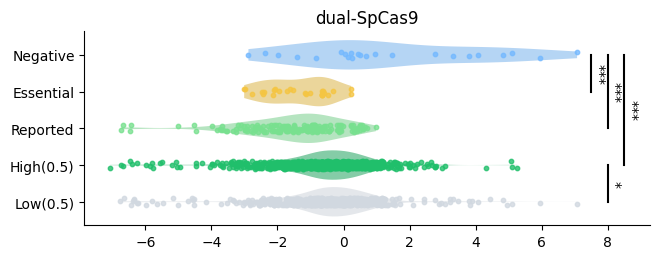

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_ind
dualKO_data = pd.read_csv('data/fig3/dualKO_K562.annotated.txt',sep='\t')
ess_lfc  = dualKO_data.loc[dualKO_data['id'].str.contains('\*'), 'neg|lfc'].dropna()
nf_lfc   = dualKO_data.loc[dualKO_data['id'].str.contains('CCR5|AAVS1|ROSA'), 'neg|lfc'].dropna()
rep_lfc  = dualKO_data.loc[dualKO_data['RRA'] > 0, 'neg|lfc'].dropna()
high_lfc = dualKO_data.loc[dualKO_data['Base_K562_pred'] > 0.5, 'neg|lfc'].dropna()
low_lfc  = dualKO_data.loc[dualKO_data['Base_K562_pred'] < 0.5, 'neg|lfc'].dropna()
result_df = pd.DataFrame()
for group_name, data in zip(
    ['Negative', 'Essential', 'Reported', 'High(0.5)', 'Low(0.5)'],
    [nf_lfc, ess_lfc, rep_lfc, high_lfc, low_lfc]
):
    temp_df = pd.DataFrame({
        'LFC': data.values,
        'CREtype': group_name
    })
    result_df = pd.concat([result_df, temp_df], ignore_index=True)
cre_order = ['Negative', 'Essential', 'Reported', 'High(0.5)', 'Low(0.5)']
COLORS = {
    'Essential': '#F5C542',
    'Negative': '#74b9ff',
    'Reported': '#78e08f',
    'High(0.5)': '#20bf6b',
    'Low(0.5)': '#d1d8e0'
}
color_list = [COLORS[cre] for cre in cre_order]
fig, ax = plt.subplots(figsize=(6.7, 2.7))
parts = sns.violinplot(
    x="LFC",
    y="CREtype",
    data=result_df,
    order=cre_order,
    palette=color_list,
    inner=None,
    cut=0,
    scale='width',
    ax=ax
)
for i, pc in enumerate(ax.collections):
    if i < len(cre_order):
        pc.set_alpha(0.6)
        pc.set_edgecolor('none')
        pc.set_linewidth(1)
for i, cre in enumerate(cre_order):
    data = result_df[result_df['CREtype'] == cre]
    y = i + np.random.uniform(-0.1, 0.1, size=len(data))
    x = data['LFC']
    ax.scatter(
        x, y,
        color=color_list[i],
        alpha=0.8,
        s=10,
        zorder=3
    )
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('dual-SpCas9')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.plot([7.5, 7.5], [1, 0], color='k')
plt.text(x=7.5, y=0.5, s='***', rotation=-90, va='center')
plt.plot([8.0, 8.0], [2, 0], color='k')
plt.text(x=8.0, y=1.0, s='***', rotation=-90, va='center')
plt.plot([8.5, 8.5], [3, 0], color='k')
plt.text(x=8.5, y=1.5, s='***', rotation=-90, va='center')
plt.plot([8.0, 8.0], [3, 4], color='k')
plt.text(x=8.0, y=3.5, s='*', rotation=-90, va='center')
plt.tight_layout()
plt.savefig('figures/Fig3i_dualKO.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Figure 3j

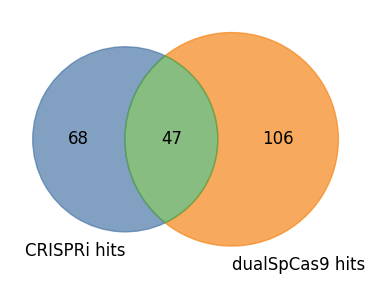

In [63]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
crispri_hits = 115
dualko_hits = 153
overlap = 47
crispri_only = crispri_hits - overlap
dualko_only = dualko_hits - overlap
fig, ax = plt.subplots(figsize=(4, 4))
venn = venn2(
    subsets=(crispri_only, dualko_only, overlap),
    set_labels=("CRISPRi hits", "dualSpCas9 hits"),
    ax=ax
)
venn.get_patch_by_id('10').set_color('#4C78A8')
venn.get_patch_by_id('01').set_color('#F58518')
venn.get_patch_by_id('11').set_color('#54A24B')
for region in ['10', '01', '11']:
    venn.get_patch_by_id(region).set_alpha(0.7)
for text in venn.set_labels:
    text.set_fontsize(12)
for text in venn.subset_labels:
    if text:
        text.set_fontsize(12)
plt.tight_layout()
plt.savefig(
    "figures/CRISPRi_dualKO_venn.pdf",
    bbox_inches="tight"
)
plt.show()


# Figure 3k

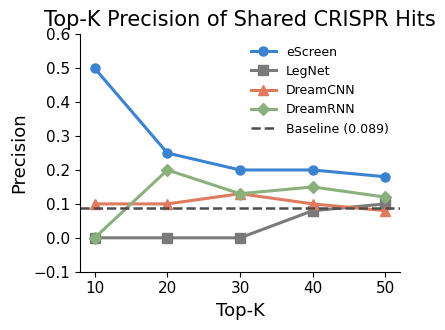

In [64]:
import os
import pandas as pd
import matplotlib.pyplot as plt
os.makedirs("./fig3_val_screen", exist_ok=True)
topk = [10, 20, 30, 40, 50]
baseline = 0.089
results = {
    "eScreen":     [0.50, 0.25, 0.20, 0.20, 0.18],
    "LegNet":      [0.00, 0.00, 0.00, 0.08, 0.10],
    "DreamCNN":    [0.10, 0.10, 0.13, 0.10, 0.08],
    "DreamRNN":    [0.00, 0.20, 0.13, 0.15, 0.12],
}
colors = {
    "eScreen":     "#3B82D0",
    "LegNet":      "#7A7A7A",
    "DreamCNN":    "#E07A5F",
    "DreamRNN":    "#8AB17D",
}
markers = {
    "eScreen":     "o",
    "LegNet":      "s",
    "DreamCNN":    "^",
    "DreamRNN":    "D",
}
fig, ax = plt.subplots(figsize=(4.2, 3.4))
for name, values in results.items():
    ax.plot(
        topk,
        values,
        marker=markers[name],
        linewidth=2.2,
        markersize=6.5,
        label=name,
        color=colors[name],
    )
ax.axhline(
    y=baseline,
    color="#4D4D4D",
    linestyle="--",
    linewidth=1.8,
    label=f"Baseline ({baseline:.3f})"
)
ax.set_xlabel("Top-K", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Top-K Precision of Shared CRISPR Hits", fontsize=15)
ax.set_xticks(topk)
ax.set_ylim(-0.1, 0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper right"
)
plt.tight_layout()
plt.savefig(
    "figures/eScreen_topk_precision.pdf",
    bbox_inches="tight"
)
plt.show()

# Figure 3l

Saved figures/Fig3l_CRISPRi.pdf


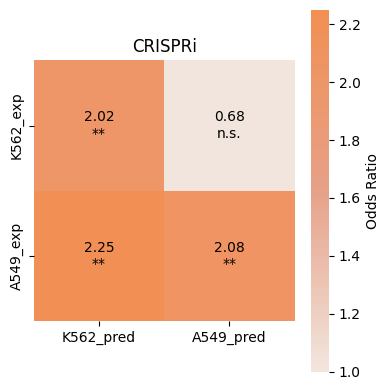

Saved figures/Fig3l_dual_SpCas9.pdf


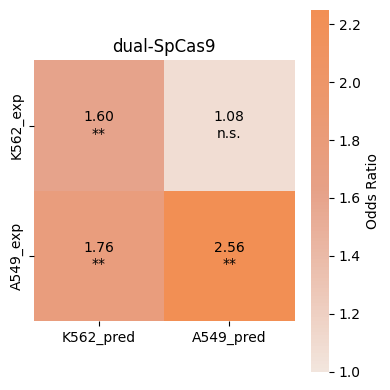

In [65]:
import pickle, os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
with open('data/fig3/SpecificHeatmap_data.pkl', 'rb') as f:
    results = pickle.load(f)
colors = ["#F2E5DD","#E6A188","#F28F54"]
cmap = LinearSegmentedColormap.from_list("RedWhite", colors, N=100)
for label in ['CRISPRi', 'dual-SpCas9']:
    OR_table = results[label]['OR_table']
    P_table = results[label]['P_table']
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(OR_table, annot=False, cmap=cmap, vmin=1.0, vmax=2.25,
                cbar_kws={'label': 'Odds Ratio'}, square=True, ax=ax)
    for i in range(2):
        for j in range(2):
            text = f"{OR_table[i, j]:.2f}\n{P_table[i, j]}"
            ax.text(j + 0.5, i + 0.5, text, ha='center', va='center',
                    fontsize=10, color='black')
    ax.set_xticklabels(['K562_pred', 'A549_pred'])
    ax.set_yticklabels(['K562_exp', 'A549_exp'])
    ax.set_title(label)
    fig.tight_layout()
    out_pdf = f'figures/Fig3l_{label.replace("-","_")}.pdf'
    os.makedirs('results', exist_ok=True)
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    print(f'Saved {out_pdf}')
    plt.show()
